# Clustering tipologie di tratti stradali e stili di guida

## Setup

In [84]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')
RANDOM_STATE = 42

DATA = Path("./outputs/ved_enriched.parquet")
df = pd.read_parquet(DATA)
print(f"shape del dataset {df.shape}")

shape del dataset (17922869, 21)


## Definizione di "segmento stradale"

Un segmento è una cella della griglia geografica (11×8m).

Per ogni cella calcoliamo statistiche aggregate del comportamento dei veicoli che ci sono passati:
- velocità media e std
- accelerazione media e std
- MAF medio
- RPM medio
- pendenza
- numero di passaggi (per il filtro=

In [85]:
# Bin spaziali da ~11x8 m (arrotondamento di lat/lon a 4 decimali)
df['lat_bin'] = df['Latitude_deg'].round(4)
df['lon_bin'] = df['Longitude_deg'].round(4)

agg = df.groupby(['lat_bin', 'lon_bin']).agg(
    n_passages=('MAF_g_per_sec', 'size'),
    speed_mean=('Vehicle_Speed_km_per_h', 'mean'),
    speed_std=('Vehicle_Speed_km_per_h', 'std'),
    accel_mean=('accel_kmh_s', 'mean'),
    accel_std=('accel_kmh_s', 'std'),
    accel_abs_mean=('accel_kmh_s', lambda s: s.abs().mean()),  # entropia di accelerazione
    maf_mean=('MAF_g_per_sec', 'mean'),
    rpm_mean=('Engine_RPM_RPM', 'mean'),
    load_mean=('Absolute_Load_pct', 'mean'),
    slope_mean=('slope', 'mean'),
    elevation=('elevation_m', 'mean'),
).reset_index()

# Frazione di stop (speed=0)
stops = df.groupby(['lat_bin', 'lon_bin'])['Vehicle_Speed_km_per_h'].apply(
    lambda s: (s < 2).mean()).reset_index(name='stop_fraction')
agg = agg.merge(stops, on=['lat_bin', 'lon_bin'])

print(f"Celle totali: {len(agg):,}")
print(f"Range n_passages: [{agg['n_passages'].min()}, {agg['n_passages'].max()}]")
agg.head()

Celle totali: 281,494
Range n_passages: [1, 3956]


,lat_bin,lon_bin,n_passages,speed_mean,speed_std,accel_mean,accel_std,accel_abs_mean,maf_mean,rpm_mean,load_mean,slope_mean,elevation,stop_fraction
0,42.220299,-83.797203,3,64.000000,2.000000,-2.888889,3.421068,2.888889,2.846667,1174.666626,14.509804,-0.017660,272.0,0.0
1,42.220299,-83.796204,4,63.500000,3.696846,2.424423,1.126853,2.424423,30.075001,1737.000000,65.882355,0.003965,275.0,0.0
2,42.220299,-83.767197,4,36.500000,1.290994,1.655844,2.263432,1.655844,7.810000,1160.000000,35.294117,-0.075000,258.0,0.0
3,42.220299,-83.760902,5,35.000000,1.870829,-3.363636,6.520787,3.363636,3.978000,1304.800049,12.549020,0.060000,294.0,0.0
4,42.220299,-83.760803,6,42.666668,1.366260,-0.694444,1.107633,0.694444,4.763333,1590.166626,15.882354,0.050000,294.0,0.0


### Pulizie di celle con pochi passaggi

necessario perché i dati potrebbero venire falsati da pochi passaggi "straordinari", come qualcuno che va molto veloce in zona urbana o pochi passaggi in autostrada ma tutti in momenti di coda

Celle: 281,494 totali -> 77,325 tenute, 204,169 scartate (< 50 passaggi)


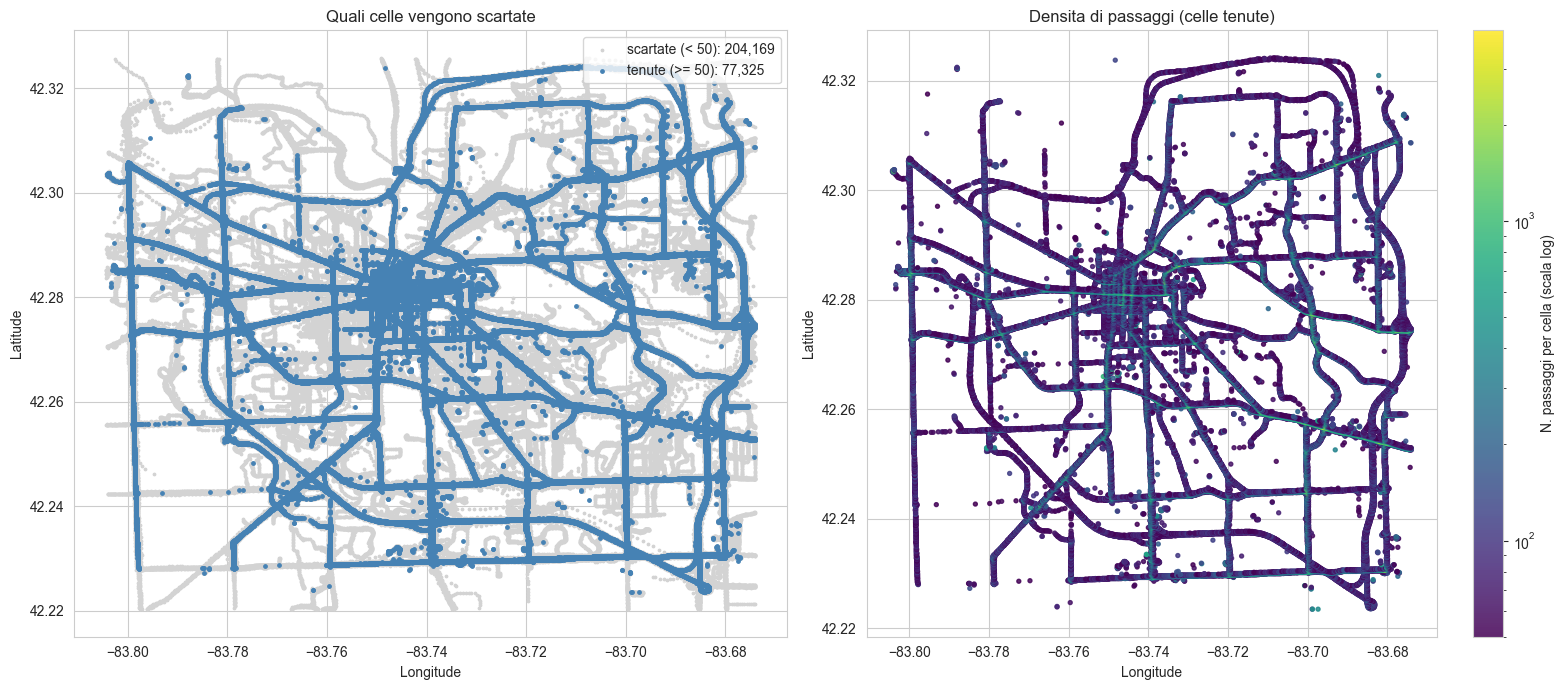

In [86]:
MIN_PASSAGES = 50
mask_keep = agg['n_passages'] >= MIN_PASSAGES
print(f"Celle: {len(agg):,} totali -> {mask_keep.sum():,} tenute, "
      f"{(~mask_keep).sum():,} scartate (< {MIN_PASSAGES} passaggi)")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# SINISTRA: QUALI celle si scartano (grigio) vs si tengono (blu) — rende visibile lo scarto
ax = axes[0]
ax.scatter(agg.loc[~mask_keep, 'lon_bin'], agg.loc[~mask_keep, 'lat_bin'],
           s=3, c='lightgray', label=f'scartate (< {MIN_PASSAGES}): {(~mask_keep).sum():,}')
ax.scatter(agg.loc[mask_keep, 'lon_bin'], agg.loc[mask_keep, 'lat_bin'],
           s=6, c='steelblue', label=f'tenute (>= {MIN_PASSAGES}): {mask_keep.sum():,}')
ax.set_title('Quali celle vengono scartate')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(loc='upper right')

# DESTRA: densita di passaggi sulle tenute, scala LOG
# (con scala lineare gli outlier a ~4000 schiacciano tutto il resto sul fondo -> "sembra vuoto")
ax = axes[1]
kept = agg[mask_keep]
sc = ax.scatter(kept['lon_bin'], kept['lat_bin'], c=kept['n_passages'],
                cmap='viridis', s=8, alpha=0.85,
                norm=LogNorm(vmin=MIN_PASSAGES, vmax=kept['n_passages'].max()))
plt.colorbar(sc, ax=ax, label='N. passaggi per cella (scala log)')
ax.set_title('Densita di passaggi (celle tenute)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

# Applica il filtro DOPO aver disegnato (cosi il pannello sinistro puo mostrare anche le scartate)
agg = agg[mask_keep].reset_index(drop=True)

## Selezione delle feature per il clustering

Feature scelte del tratto: velocità (media/std), accelerazione
(media/std/abs), frazione di sosta (`stop_fraction`) e pendenza (`slope_mean`).

**Esclusi i segnali-motore** `maf_mean`, `rpm_mean`, `load_mean`: (a) sono **ridondanti** tra loro
(RPM/Load correlano col MAF 0,75 e 0,52).

Escludiamo anche `n_passages` (meta-dato), `elevation` (quota **assoluta**) e le coordinate (stesso motivo).

In [87]:
FEATURES_CLUSTER = [
    'speed_mean', 'speed_std',
    'accel_mean', 'accel_std', 'accel_abs_mean',
    'slope_mean', 'stop_fraction'
]
# Esclusi di proposito maf_mean/rpm_mean/load_mean (segnali-motore): ridondanti + rendono il
# cluster leaky rispetto al consumo. Solo cinematica + geometria (coerente con la Parte B).

X = agg[FEATURES_CLUSTER].copy()
X = X.dropna()  # alcune celle potrebbero avere std NaN con un solo passaggio
agg_clean = agg.loc[X.index].reset_index(drop=True)
X = X.reset_index(drop=True)
print(f"Celle finali per clustering: {len(X):,}")
print(f"Feature: {len(FEATURES_CLUSTER)}")

X.describe()

Celle finali per clustering: 77,325
Feature: 7


,speed_mean,speed_std,accel_mean,accel_std,accel_abs_mean,slope_mean,stop_fraction
count,77325.000000,77325.000000,77325.000000,77325.000000,77325.000000,77325.000000,77325.000000
mean,46.282219,14.307227,-0.146671,3.614341,1.773129,0.000124,0.077770
std,23.008968,7.086949,0.903107,0.937117,0.670067,0.018218,0.159084
min,0.000000,0.000000,-5.249651,0.000000,0.000000,-0.082192,0.000000
25%,29.344944,8.913104,-0.632350,2.974992,1.295158,-0.006121,0.000000
50%,46.254467,13.176139,-0.132034,3.613687,1.688191,0.000000,0.000000
75%,58.077103,18.334269,0.346891,4.244734,2.176733,0.006000,0.084112
max,121.697365,57.487869,4.166846,7.239012,5.437530,0.081307,1.000000


## Standardizzazione 

Guarda le scale delle feature:
- `speed_mean`: 0–120 km/h
- `speed_std`: 0–55
- `accel_std`: 0–7
- `stop_fraction`: 0–1
- `slope_mean`: -0.08 a 0.08

In [88]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES_CLUSTER)
print(X_scaled_df.describe().loc[['mean', 'std']].round(3))

      speed_mean  speed_std  accel_mean  accel_std  accel_abs_mean  \
mean         0.0        0.0        -0.0       -0.0            -0.0   
std          1.0        1.0         1.0        1.0             1.0   

      slope_mean  stop_fraction  
mean         0.0            0.0  
std          1.0            1.0  


## Elbow Method e Silhouette per il numero di cluster

Provo da 2 a 10 e vedo come si comportano i grafici

  k=2: inertia=423786, silhouette=0.227
  k=3: inertia=353914, silhouette=0.250
  k=4: inertia=312365, silhouette=0.254
  k=5: inertia=271749, silhouette=0.246
  k=6: inertia=246614, silhouette=0.257
  k=7: inertia=223410, silhouette=0.245
  k=8: inertia=206727, silhouette=0.219
  k=9: inertia=192350, silhouette=0.226
  k=10: inertia=183357, silhouette=0.210


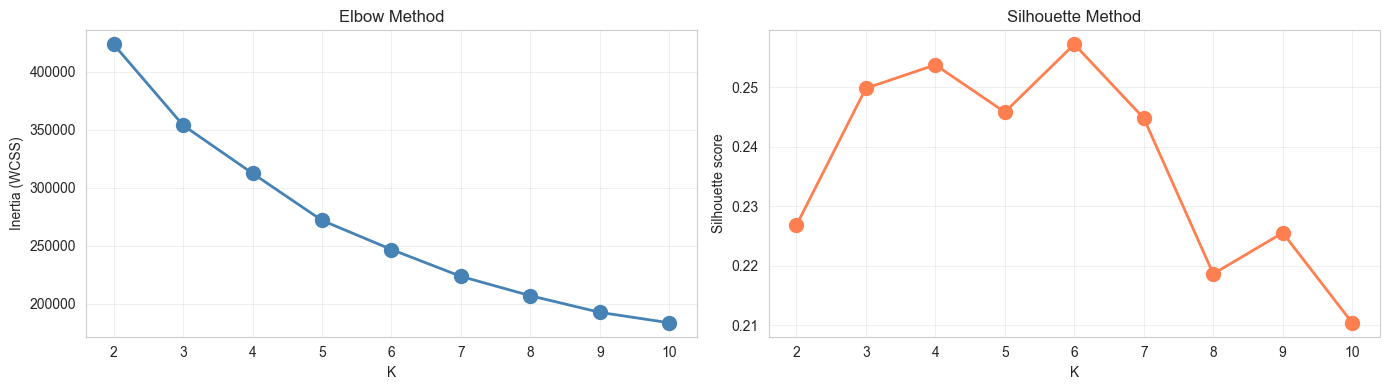

In [89]:
K_VALUES = list(range(2, 11))
inertias = []
silhouettes = []

# Silhouette è costosa: usiamo un sample per K alti
if len(X_scaled) > 10000:
    sil_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=10000, replace=False)
else:
    sil_idx = np.arange(len(X_scaled))

for k in K_VALUES:
    km = KMeans(n_clusters=k, n_init=20, init='k-means++', random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled[sil_idx], labels[sil_idx])
    silhouettes.append(sil)
    print(f"  k={k}: inertia={km.inertia_:.0f}, silhouette={sil:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(K_VALUES, inertias, 'o-', color='steelblue', lw=2, markersize=10)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_VALUES, silhouettes, 'o-', color='coral', lw=2, markersize=10)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Method')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Scelta finale
ad occhio le uniche fattibili sono 4 e 6, dopo aver fatto due prove con il modello la migliore è 4

In [90]:
K_FINAL=4

## K-Means 
Di seguito il kmeans con il numero di k scelto e K-Means++ come inizializzazione perché sceglie centroidi iniziali distanti tra loro.

In [91]:
kmeans = KMeans(n_clusters=K_FINAL, n_init=50, init='k-means++', random_state=RANDOM_STATE)
labels = kmeans.fit_predict(X_scaled)
agg_clean['cluster'] = labels

print(agg_clean['cluster'].value_counts().sort_index())

cluster
0    31792
1     7951
2     5738
3    31844
Name: count, dtype: int64


## Sssegnazione nomi ai cluster

guardando le feature di clustering più il maf aggiunto come colonna descrittiva cerchiamo di capire a che tipologie di strade appartiene ogni cluster

In [92]:
# Profilo dei cluster: medie delle FEATURE DI CLUSTERING (cinematica + geometria)
cluster_profile = agg_clean.groupby('cluster')[FEATURES_CLUSTER + ['n_passages']].mean().round(2)
cluster_profile['count'] = agg_clean['cluster'].value_counts().sort_index()

# --- Colonna DESCRITTIVA (NON usata per clusterizzare) ---
# Consumo medio per tipologia di tratto. I cluster sono formati SOLO su cinematica+geometria:
# se risultano separati anche nel consumo e' un RISULTATO a posteriori, non una tautologia.
cluster_profile['maf_mean_descr'] = agg_clean.groupby('cluster')['maf_mean'].mean().round(2)

cluster_profile

,speed_mean,speed_std,accel_mean,accel_std,accel_abs_mean,slope_mean,stop_fraction,n_passages,count,maf_mean_descr
cluster,,,,,,,,,,
0,33.740002,15.530000,-0.30,4.46,2.38,0.0,0.08,242.33,31792,9.45
1,79.250000,27.139999,0.00,3.07,1.38,-0.0,0.03,122.76,7951,16.74
2,11.110000,13.280000,-0.08,2.95,1.14,-0.0,0.53,275.58,5738,6.31
3,56.910000,10.070000,-0.04,3.03,1.38,0.0,0.00,151.89,31844,10.23


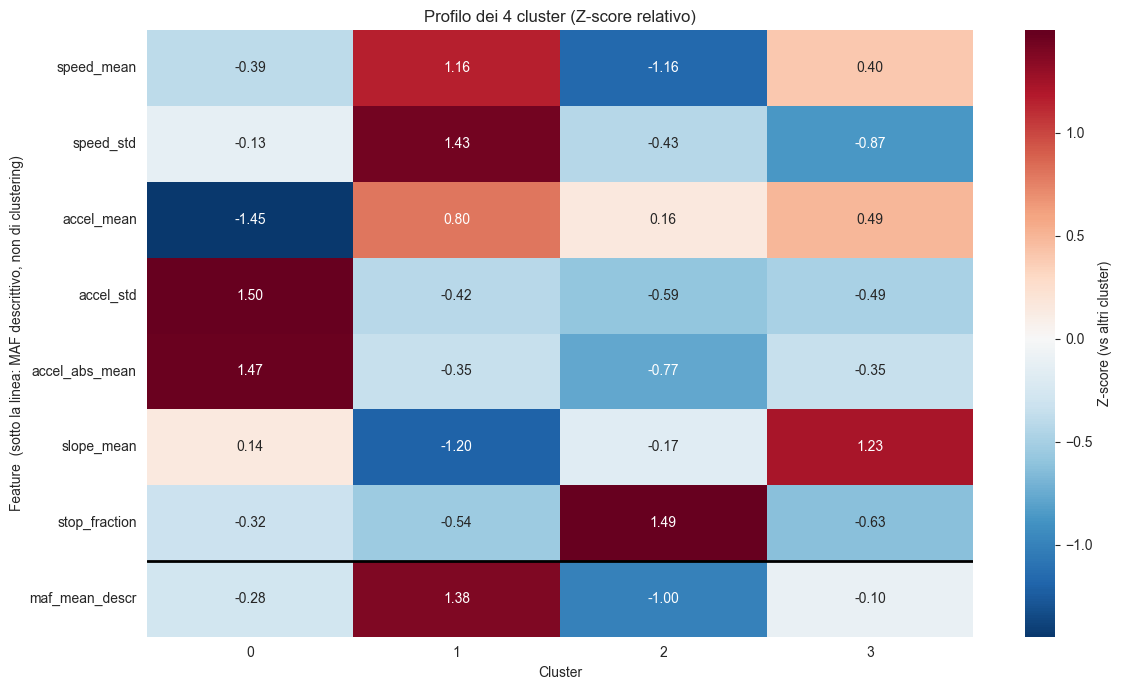

In [93]:
# Heatmap dei profili cluster (z-score per riga, su tutti i cluster).
# Usiamo le medie NON arrotondate: slope_mean e' ~0.00x e con round(2) diventerebbe 0.00 per
# tutti i cluster -> varianza 0 -> z-score NaN -> la riga sparirebbe dalla heatmap.
# Aggiungiamo anche maf_mean come riga DESCRITTIVA (non ha formato i cluster), sotto una linea.
HEAT_COLS = FEATURES_CLUSTER + ['maf_mean']
profile_full = (agg_clean.groupby('cluster')[HEAT_COLS].mean()
                .rename(columns={'maf_mean': 'maf_mean_descr'}))
profile_norm = (profile_full - profile_full.mean()) / profile_full.std()

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(profile_norm.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Z-score (vs altri cluster)'}, ax=ax)
# linea che separa le 7 feature di clustering dal MAF (descrittivo, NON usato per formare i cluster)
ax.axhline(len(FEATURES_CLUSTER), color='black', lw=2)
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature  (sotto la linea: MAF descrittivo, non di clustering)')
ax.set_title(f'Profilo dei {K_FINAL} cluster (Z-score relativo)')
plt.tight_layout()
plt.show()

### Naming dei cluster (metodo AI)

**ATTENZIONE: i cluster K-Means non hanno un ordinamento fisso** — a ogni riesecuzione gli stessi
pattern possono avere ID diversi. Per questo li nominiamo **in base ai valori del profilo**, non al
numero: così il nome resta corretto anche se gli ID si rimescolano.

**Logica di naming** (cella sotto), in ordine di priorità:
- `stop_fraction > 0,50` → **Incrocio/semaforo** (quasi sempre fermo)
- `stop_fraction > 0,18` → **Urbano stop-and-go** (molte soste, ma in movimento)
- `speed_mean ≥ 75` → **Autostrada/scorrimento veloce**
- `speed_mean ≥ 50` → **Scorrevole/arteria fluida** (veloce ma regolare)
- velocità moderata + poche soste → distinta per **segno dell'accelerazione media**:
  - `accel_mean > 0` → **Ripartenze/accelerazione**
  - `accel_mean < 0` → **Avvicinamento a incroci/decelerazione**

Le soglie sono cutoff **interpretabili** (regolabili). Verifica sempre col profilo/heatmap qui sopra.

In [94]:
# Naming dei cluster basato sui VALORI del profilo (robusto al rinumeramento del K-Means).
# Logica: frazione di sosta -> livello di velocita' -> segno dell'accelerazione media.
def name_cluster(row):
    sp, stop, am = row['speed_mean'], row['stop_fraction'], row['accel_mean']
    if stop > 0.50:                       # fermo per la maggior parte del tempo
        return 'Incrocio/semaforo'
    if stop > 0.18:                       # molte soste, ma in movimento
        return 'Ambiente urbano'
    if sp >= 60:                          # alta velocita', quasi nessuna sosta
        return 'Autostrada'
    if sp >= 50:                          # velocita' sostenuta e regolare
        return 'Strada statale scorrevole'
    # velocita' moderata + poche soste: distinguo per il segno dell'accelerazione media
    if am > 0.4:
        return 'Ripartenze/tratto in accelerazione'
    if am < -0.4:
        return 'Avvicinamento a incroci/decelerazione'
    return 'Cittadino misto'

cluster_profile['cluster_name'] = cluster_profile.apply(name_cluster, axis=1)
cluster_names = cluster_profile['cluster_name'].to_dict()

print("Naming (assegnato dai valori del profilo):")
for k, v in cluster_names.items():
    print(f"  Cluster {k}: {v:42s} "
          f"[speed={cluster_profile.loc[k, 'speed_mean']:.0f}, "
          f"stop={cluster_profile.loc[k, 'stop_fraction']:.2f}, "
          f"accel_mean={cluster_profile.loc[k, 'accel_mean']:+.2f}]")

# Mappa l'etichetta nei dati
agg_clean['cluster_name'] = agg_clean['cluster'].map(cluster_names)

Naming (assegnato dai valori del profilo):
  Cluster 0: Cittadino misto                            [speed=34, stop=0.08, accel_mean=-0.30]
  Cluster 1: Autostrada                                 [speed=79, stop=0.03, accel_mean=+0.00]
  Cluster 2: Incrocio/semaforo                          [speed=11, stop=0.53, accel_mean=-0.08]
  Cluster 3: Strada statale scorrevole                  [speed=57, stop=0.00, accel_mean=-0.04]


## 8. Visualizzazione PCA dei cluster

Proiettiamo le celle (feature di clustering standardizzate) sulle prime due componenti principali per *vedere* in 2D quanto i cluster sono separati.

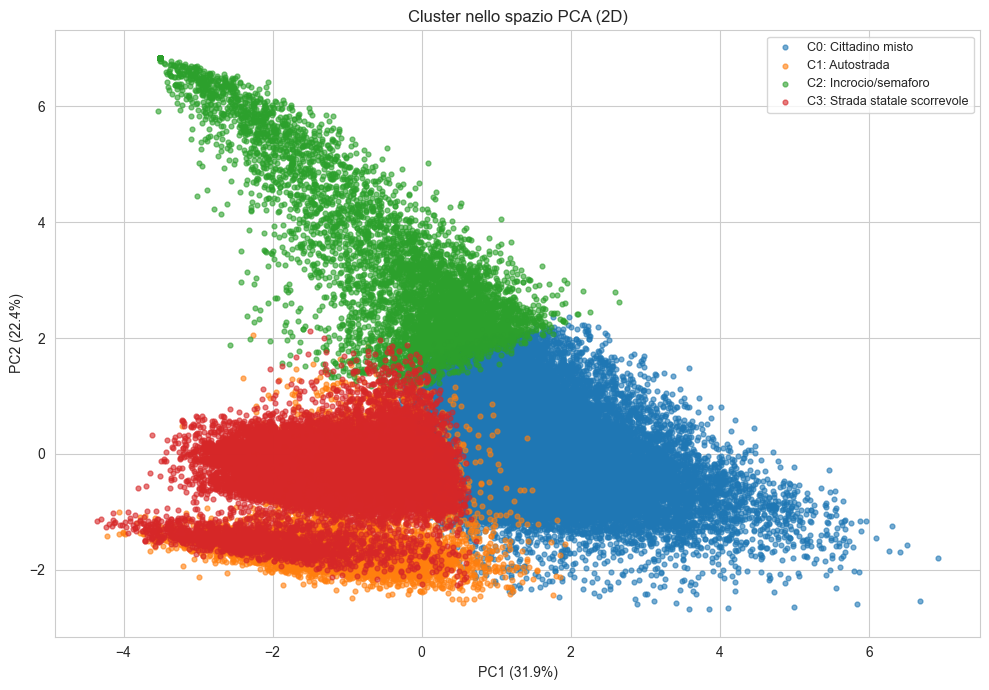

In [95]:
# PCA 2D delle feature di clustering standardizzate (per visualizzare la separazione)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('tab10', K_FINAL)
for c in sorted(agg_clean['cluster'].unique()):
    mask = agg_clean['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=12, alpha=0.6, color=palette[c],
               label=f'C{c}: {cluster_names[c]}')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Cluster nello spazio PCA (2D)')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Visualizzazione geografica — la mappa di Ann Arbor

**Questa è la sezione "deliverable visivo"** del progetto. Coloriamo la mappa di Ann Arbor con i cluster, ottenendo una vera classificazione geografica dei tipi di tratto stradale.

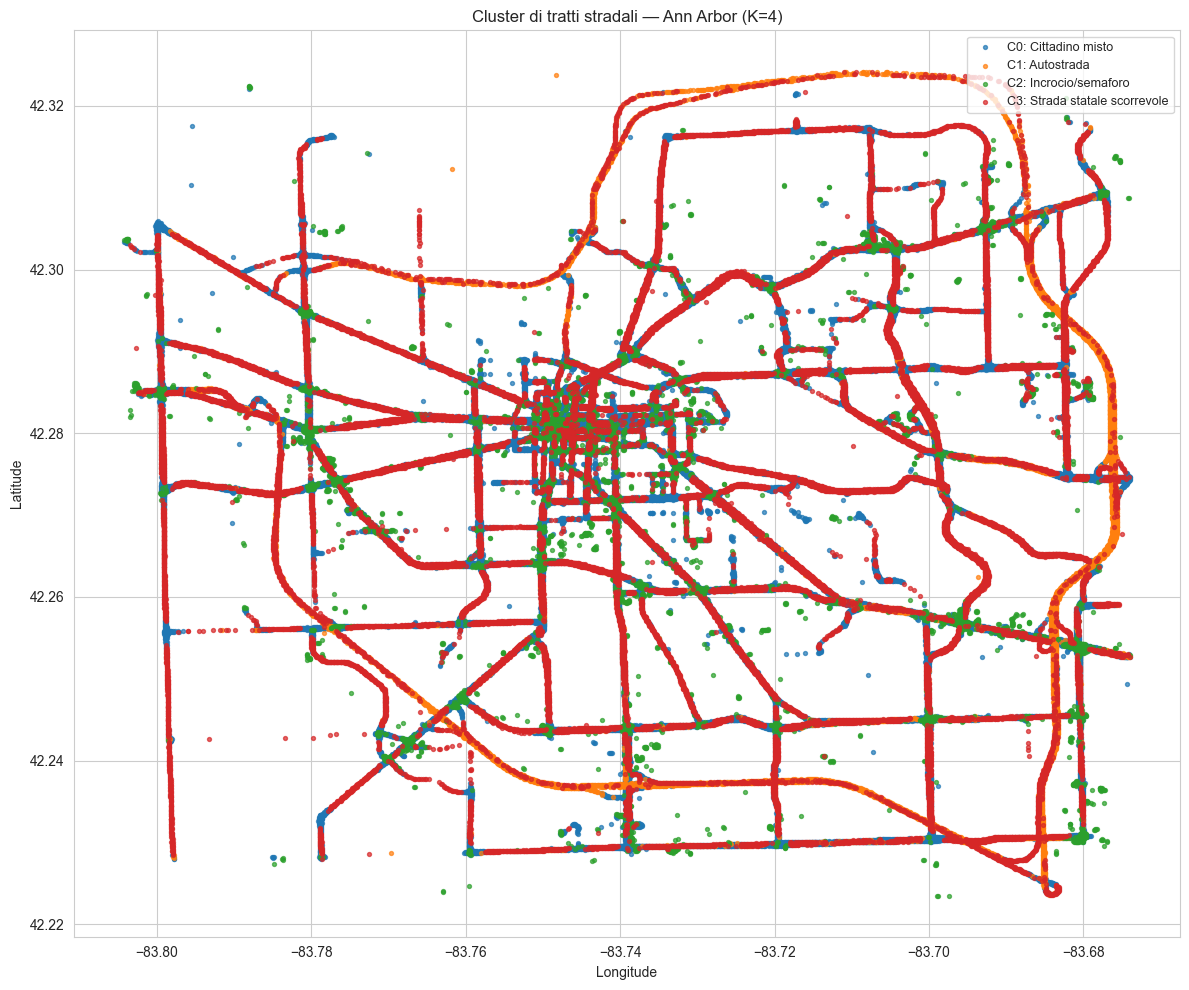

In [96]:
# Plot statico (matplotlib) — sempre disponibile
fig, ax = plt.subplots(figsize=(12, 10))
for c in sorted(agg_clean['cluster'].unique()):
    mask = agg_clean['cluster'] == c
    ax.scatter(agg_clean.loc[mask, 'lon_bin'], agg_clean.loc[mask, 'lat_bin'],
               s=8, alpha=0.7, color=palette[c],
               label=f'C{c}: {cluster_names[c]}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Cluster di tratti stradali — Ann Arbor (K={K_FINAL})')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()  # mappa statica solo a schermo (il file salvato e' l'HTML interattivo)

In [97]:
try:
    import folium
    center = [agg_clean['lat_bin'].mean(), agg_clean['lon_bin'].mean()]
    m = folium.Map(location=center, zoom_start=13, tiles='cartodbpositron')

    # Palette hex per folium
    palette_hex = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'
                   for r, g, b in palette]

    # Subsample per non appesantire la mappa (~10k punti totali)
    plot_df = agg_clean.sample(n=min(10000, len(agg_clean)), random_state=RANDOM_STATE)

    # Un FeatureGroup per ogni cluster -> diventa una voce SPUNTABILE nel controllo dei layer.
    # show=True: parte visibile; togli la spunta per nascondere quel cluster.
    for c in sorted(agg_clean['cluster'].unique()):
        fg = folium.FeatureGroup(name=f'C{c}: {cluster_names[c]}', show=True)
        sub = plot_df[plot_df['cluster'] == c]
        for _, row in sub.iterrows():
            folium.CircleMarker(
                location=[row['lat_bin'], row['lon_bin']],
                radius=3,
                color=palette_hex[c],
                fill=True,
                fill_opacity=0.7,
                popup=f"Cluster {c}: {cluster_names[c]}<br>"
                      f"Speed={row['speed_mean']:.1f} km/h<br>"
                      f"MAF={row['maf_mean']:.1f} g/s<br>"
                      f"Stop frac={row['stop_fraction']:.2f}"
            ).add_to(fg)
        fg.add_to(m)

    # Pannello di controllo: spunta/togli ogni cluster (overlay -> caselle multiple, non radio).
    # collapsed=False lo lascia aperto cosi si vede subito.
    folium.LayerControl(collapsed=False).add_to(m)

    # Legenda colori (il pannello dei layer mostra i nomi, questa mostra i colori)
    legend_html = ('<div style="position: fixed; bottom: 30px; left: 30px; width: 250px; '
                   'background: white; border:2px solid grey; padding: 10px; z-index: 1000;">'
                   '<b>Colori cluster</b><br>')
    for c, name in cluster_names.items():
        legend_html += (f'<i style="background:{palette_hex[c]}; width:12px; height:12px; '
                        f'display:inline-block;"></i> C{c}: {name}<br>')
    legend_html += '</div>'
    m.get_root().html.add_child(folium.Element(legend_html))

    OUT_MAP = Path('./outputs/cluster_map.html')
    m.save(str(OUT_MAP))
    print(f"✓ Mappa interattiva salvata: {OUT_MAP}")
    print("  Apri il file HTML: usa il pannello in alto a destra per mostrare/nascondere i cluster.")
except ImportError:
    print("folium non installato. Installa con: pip install folium")
    print("Per ora va bene la mappa statica salvata sopra.")

✓ Mappa interattiva salvata: outputs\cluster_map.html
  Apri il file HTML: usa il pannello in alto a destra per mostrare/nascondere i cluster.


## Salvataggio dei risultati

In [98]:
# Salviamo solo l'essenziale per ricordare/presentare il clustering:
#  - il PROFILO + NOME di ogni cluster (come sono fatti i cluster)
#  - la mappa interattiva HTML (gia' salvata nella cella della mappa sopra)
cluster_profile.to_csv('./outputs/cluster_profile.csv')
print("\u2713 Salvati:")
print("  outputs/cluster_profile.csv  (profilo + nome di ogni cluster = come ho clusterizzato)")
print("  outputs/cluster_map.html     (mappa interattiva, salvata sopra)")

✓ Salvati:
  outputs/cluster_profile.csv  (profilo + nome di ogni cluster = come ho clusterizzato)
  outputs/cluster_map.html     (mappa interattiva, salvata sopra)


---
# Parte B — Stili di guida

Finora (Parte A) abbiamo clusterizzato i **tratti di strada**. Ora cambiamo unita': il **guidatore**
(`VehId`). Caratterizziamo lo **stile di guida** dalla sola **cinematica** (velocita', accelerazioni,
soste) — niente MAF/RPM. Questo e' fondamentale: la cinematica e' **valida e confrontabile per tutti
e tre i powertrain** (ICE/HEV/PHEV), mentre il consumo (MAF) no (per gli ibridi il motore si spegne).

Osserviamo anche la **composizione per tipo di motore** (`EngineType`) dei gruppi di stile. In questa
versione ci fermiamo al profilo degli stili; il test statistico stile × powertrain e il confronto
energetico tra motori restano una possibile estensione.

## B.1 Profilo cinematico per guidatore

Aggreghiamo la telemetria per `VehId`: velocita' media/variabilita'/crociera (p85), accelerazione
media e brusca, frenate brusche, frazione di sosta. Niente MAF/RPM -> feature powertrain-agnostiche.

In [99]:
g = df.groupby('VehId')
driver = g.agg(
    EngineType=('EngineType', 'first'),
    n=('VehId', 'size'),
    speed_mean=('Vehicle_Speed_km_per_h', 'mean'),
    speed_std=('Vehicle_Speed_km_per_h', 'std'),
    speed_p85=('Vehicle_Speed_km_per_h', lambda s: s.quantile(0.85)),
    accel_abs_mean=('accel_kmh_s', lambda s: s.abs().mean()),
    accel_std=('accel_kmh_s', 'std'),
    frac_hard_accel=('accel_kmh_s', lambda s: (s > 6).mean()),
    frac_hard_decel=('accel_kmh_s', lambda s: (s < -6).mean()),
    stop_fraction=('Vehicle_Speed_km_per_h', lambda s: (s < 2).mean()),
).reset_index()

driver = driver[driver['n'] >= 2000].reset_index(drop=True)   # guidatori con dati sufficienti
STYLE_FEATURES = ['speed_mean','speed_std','speed_p85','accel_abs_mean','accel_std',
                  'frac_hard_accel','frac_hard_decel','stop_fraction']
print(f"Guidatori: {len(driver)} | per EngineType:")
print(driver['EngineType'].value_counts().to_string())
driver[STYLE_FEATURES].describe().round(3)

Guidatori: 278 | per EngineType:
EngineType
ICE     177
HEV      89
PHEV     12


,speed_mean,speed_std,speed_p85,accel_abs_mean,accel_std,frac_hard_accel,frac_hard_decel,stop_fraction
count,278.000,278.000,278.000,278.000,278.000,278.000,278.000,278.000
mean,41.036,25.798,66.956,1.828,3.918,0.057,0.056,0.114
std,7.869,4.614,11.911,0.243,0.286,0.009,0.008,0.082
min,8.020,14.447,23.000,0.817,2.737,0.026,0.026,0.000
25%,35.747,22.415,60.250,1.698,3.762,0.052,0.051,0.037
50%,40.423,25.262,64.000,1.841,3.950,0.058,0.055,0.124
75%,45.642,28.474,69.060,2.006,4.118,0.063,0.061,0.160
max,69.748,42.003,118.000,2.403,4.663,0.081,0.084,0.667


## B.2 Standardizzazione e scelta di K (elbow + silhouette)

  k=2: inertia=1552, silhouette=0.287
  k=3: inertia=1218, silhouette=0.290
  k=4: inertia=1050, silhouette=0.228
  k=5: inertia=912, silhouette=0.246
  k=6: inertia=807, silhouette=0.250
  k=7: inertia=714, silhouette=0.256
  k=8: inertia=646, silhouette=0.262


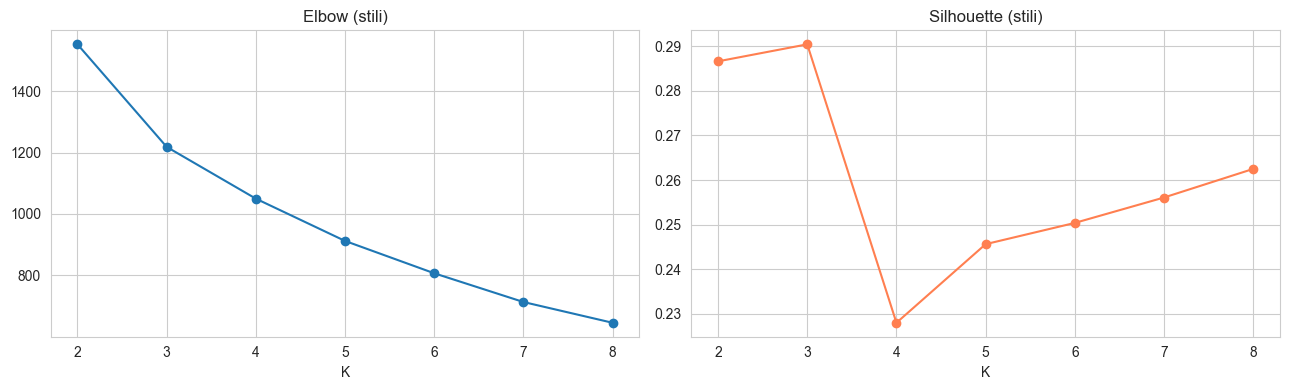

K scelto (stili): 3 (modifica a mano se preferisci il gomito)


In [100]:
Xs = StandardScaler().fit_transform(driver[STYLE_FEATURES])
Ks = list(range(2, 9)); inertias=[]; sils=[]
for k in Ks:
    km = KMeans(n_clusters=k, n_init=20, init='k-means++', random_state=RANDOM_STATE).fit(Xs)
    inertias.append(km.inertia_); sils.append(silhouette_score(Xs, km.labels_))
    print(f"  k={k}: inertia={km.inertia_:.0f}, silhouette={sils[-1]:.3f}")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(Ks, inertias, 'o-'); axes[0].set_title('Elbow (stili)'); axes[0].set_xlabel('K')
axes[1].plot(Ks, sils, 'o-', color='coral'); axes[1].set_title('Silhouette (stili)'); axes[1].set_xlabel('K')
plt.tight_layout(); plt.show()
K_STYLE = Ks[int(np.argmax([s if 3 <= k <= 6 else -1 for k, s in zip(Ks, sils)]))]
print("K scelto (stili):", K_STYLE, "(modifica a mano se preferisci il gomito)")

## B.3 K-Means, profilo e naming degli stili

Naming euristico da rivedere guardando la heatmap (come per i cluster stradali).

       speed_mean  speed_std  speed_p85  accel_abs_mean  accel_std  frac_hard_accel  frac_hard_decel  stop_fraction    n
style                                                                                                                   
0       36.113998  24.745001  60.835999           1.591      3.658            0.049            0.049          0.159   91
1       40.201000  24.080999  63.639000           1.996      4.121            0.063            0.061          0.095  131
2       50.990002  31.524000  84.662003           1.820      3.865            0.056            0.054          0.085   56


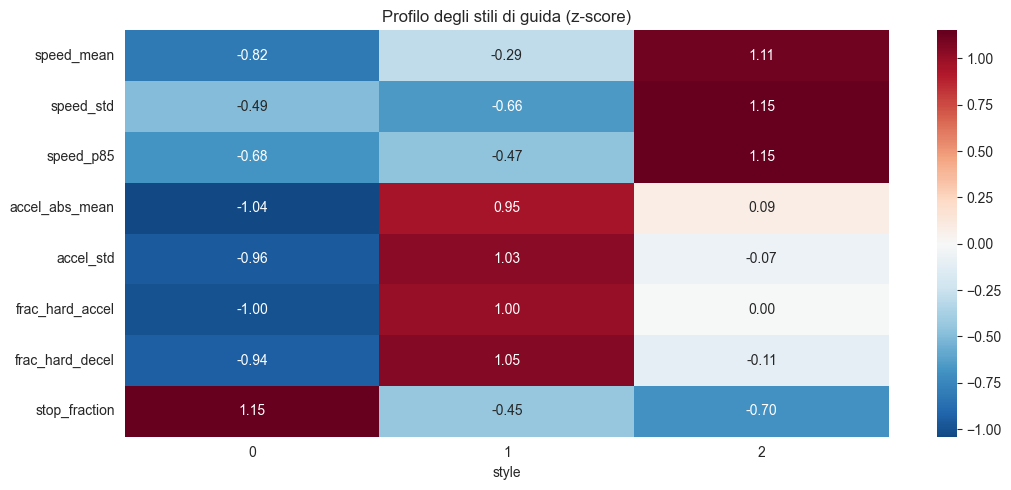


Naming proposto: {0: 'Urbano stop-and-go', 1: 'Aggressivo', 2: 'Crociera/extraurbano'}


In [101]:
km = KMeans(n_clusters=K_STYLE, n_init=50, init='k-means++', random_state=RANDOM_STATE)
driver['style'] = km.fit_predict(Xs)
prof = driver.groupby('style')[STYLE_FEATURES].mean().round(3)
prof['n'] = driver['style'].value_counts().sort_index()
print(prof.to_string())

prof_z = (prof[STYLE_FEATURES] - prof[STYLE_FEATURES].mean()) / prof[STYLE_FEATURES].std()
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(prof_z.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Profilo degli stili di guida (z-score)'); plt.tight_layout(); plt.show()

def name_style(r):
    if r['stop_fraction'] > prof['stop_fraction'].quantile(0.66): return 'Urbano stop-and-go'
    if r['frac_hard_accel'] + r['frac_hard_decel'] > (prof['frac_hard_accel']+prof['frac_hard_decel']).quantile(0.66): return 'Aggressivo'
    if r['speed_p85'] > prof['speed_p85'].quantile(0.66): return 'Crociera/extraurbano'
    return 'Moderato'
style_names = {i: name_style(prof.loc[i]) for i in prof.index}
driver['style_name'] = driver['style'].map(style_names)
print("\nNaming proposto:", style_names)

## B.4 PCA degli stili

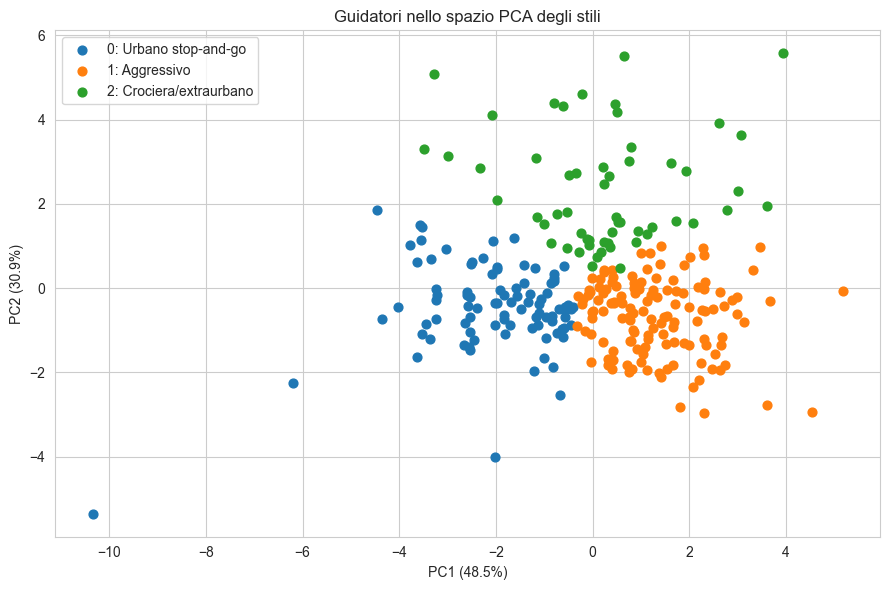

In [102]:
pca_s = PCA(n_components=2, random_state=RANDOM_STATE)
Zs = pca_s.fit_transform(Xs)
fig, ax = plt.subplots(figsize=(9, 6))
pal = sns.color_palette('tab10', K_STYLE)
for c in sorted(driver['style'].unique()):
    m = driver['style'] == c
    ax.scatter(Zs[m, 0], Zs[m, 1], s=40, color=pal[c], label=f"{c}: {style_names[c]}")
ax.set_xlabel(f'PC1 ({pca_s.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_s.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Guidatori nello spazio PCA degli stili'); ax.legend(); plt.tight_layout(); plt.show()

---

## Riepilogo finale

**Cosa abbiamo costruito:**
- Aggregazione spaziale dei 17M punti in ~migliaia di celle (~11×8 m)
- Filtro qualità (≥ 50 passaggi per cella)
- Standardizzazione con motivazione esplicita (dimostrazione del fallimento senza scaling)
- Elbow + Silhouette per scelta di K
- K-Means con K-Means++ e n_init=50
- Caratterizzazione e naming dei cluster con heatmap z-score
- PCA con interpretazione dei loadings
- Mappa geografica statica + interattiva di Ann Arbor con cluster

**Collegamento con il Notebook 2:** i cluster **descrivono** il contesto, non alimentano il modello di consumo. Darli in pasto al NB2 non aggiungerebbe informazione (sono una compressione delle feature cinematiche già presenti nel NB2) e quando erano costruiti sul MAF introducevano *leakage*. Restano quindi un livello interpretativo parallelo: la narrativa del cruise control predittivo si chiude con NB1 (geometria) + NB2 (costo) + NB3 (contesto), non concatenandoli ingenuamente.

**Limitazioni (da menzionare nella presentazione):**
- K-Means assume cluster sferici e di dimensione simile; alternative come DBSCAN o HDBSCAN potrebbero trovare cluster di forma diversa
- L'aggregazione spaziale a celle quadrate è approssimativa: una segmentazione vera su grafo stradale (OpenStreetMap) sarebbe più accurata
- I cluster sono dipendenti dall'area: applicare a un'altra città richiederebbe ri-training

---
## Riepilogo (NB3 — contesto stradale + stili di guida)

**Parte A — contesto stradale:** clustering dei tratti (celle spaziali) in tipologie di strada;
StandardScaler motivato, elbow+silhouette, K-Means++, heatmap, PCA, mappa Folium.

**Parte B — stili di guida:** clustering dei **guidatori** sulla sola **cinematica** (velocità,
accelerazioni, soste — valida per tutti i powertrain ICE/HEV/PHEV), con profilo a heatmap, naming
euristico e visualizzazione PCA.

**Tecniche del corso:** StandardScaler, K-Means/K-Means++, elbow, silhouette, PCA + loadings.